In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

df = pd.read_csv("loan_data.csv")

# Viewing first rows If the Data is Loaded or not
df.head()

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732,19210,44.13,employed,Approved


-> Input features are- Income, Loan_Amount, Credit_Score, Employment_Status
-> Target Variables - Approval(Rejected or Approved )

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Text               24000 non-null  str    
 1   Income             24000 non-null  int64  
 2   Credit_Score       24000 non-null  int64  
 3   Loan_Amount        24000 non-null  int64  
 4   DTI_Ratio          24000 non-null  float64
 5   Employment_Status  24000 non-null  str    
 6   Approval           24000 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 1.3 MB


2. DATA CLEANING and PROCESSING

-> Checking Missing Value

In [59]:
print(df.isnull().sum()) 
df = df.drop('Text', axis=1)

Text                 0
Income               0
Credit_Score         0
Loan_Amount          0
DTI_Ratio            0
Employment_Status    0
Approval             0
dtype: int64


0 missing Value Found

In [60]:
#Identifying numerical and categorical Columns
num_colmns = df.select_dtypes(include=['int64','float64']).columns
cat_colmns = df.select_dtypes(include=['object']).columns

print(num_colmns)
print(cat_colmns)

Index(['Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio'], dtype='str')
Index(['Employment_Status', 'Approval'], dtype='str')


C:\Users\tusha\AppData\Local\Temp\ipykernel_27016\1478490078.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_colmns = df.select_dtypes(include=['object']).columns


Converting Categorical Features to Numeric

In [61]:
le = LabelEncoder()

for col in cat_colmns:
    df[col] = le.fit_transform(df[col])

In [62]:
print(df)
print("1- Rejected \n0- Approved")

       Income  Credit_Score  Loan_Amount  DTI_Ratio  Employment_Status  \
0       26556           581         8314      79.26                  0   
1      197392           389       111604      22.14                  0   
2       44561           523        34118      45.44                  0   
3      190363           729       118757      10.22                  1   
4       61853           732        19210      44.13                  0   
...       ...           ...          ...        ...                ...   
23995  195242           817        16403      24.32                  0   
23996  150246           729       101572       9.97                  0   
23997   64571           650        30533      57.35                  0   
23998  115825           418        89837      10.37                  1   
23999  180440           769        15259      15.06                  0   

       Approval  
0             1  
1             1  
2             1  
3             1  
4             0  
...

Handling Class Imbalance

In [81]:
# checking Distribution
df['Approval'].value_counts(normalize=True)*100
print("Approved - 16.3875")
print('Rejected- 83.6125')

Approved - 16.3875
Rejected- 83.6125


Yes, Class Imbalance Exists.
Dropping Loan_Reason Columns

In [64]:

X = df.drop('Approval', axis=1)
y = df['Approval']

smote = SMOTE()
X, y = smote.fit_resample(X, y)

Exploratory Data Analysis

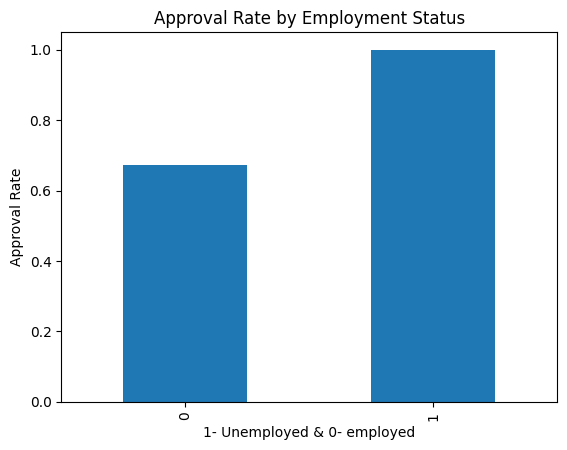

In [83]:
approval_emp = df.groupby("Employment_Status")["Approval"].mean()

plt.figure()
approval_emp.plot(kind="bar")

plt.title("Approval Rate by Employment Status")
plt.xlabel("Employment Status")
plt.xlabel("1- Unemployed & 0- employed")
plt.ylabel("Approval Rate")


plt.show()

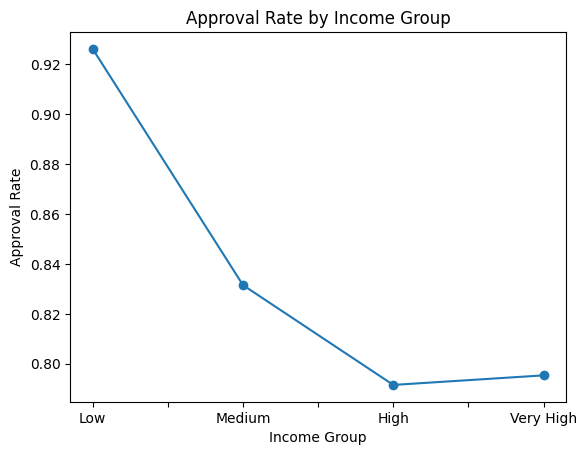

In [84]:
df["Income_Group"] = pd.qcut(df["Income"], 4, labels=["Low","Medium","High","Very High"])

approval_income = df.groupby("Income_Group")["Approval"].mean()

plt.figure()
approval_income.plot(kind="line", marker="o")

plt.title("Approval Rate by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Approval Rate")

plt.show()

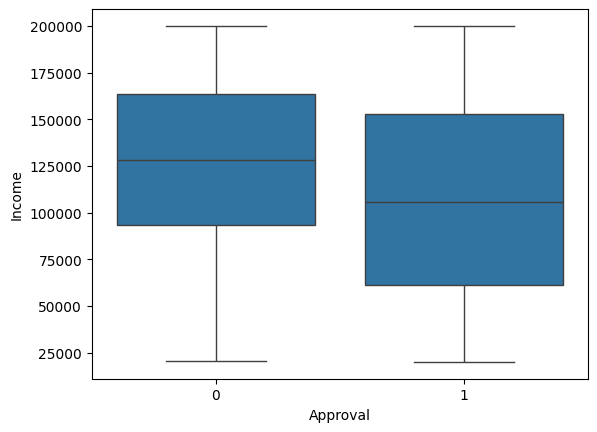

In [65]:
sns.boxplot(x='Approval', y='Income', data=df)
plt.show()
#1- Rejected 
#2- Approved

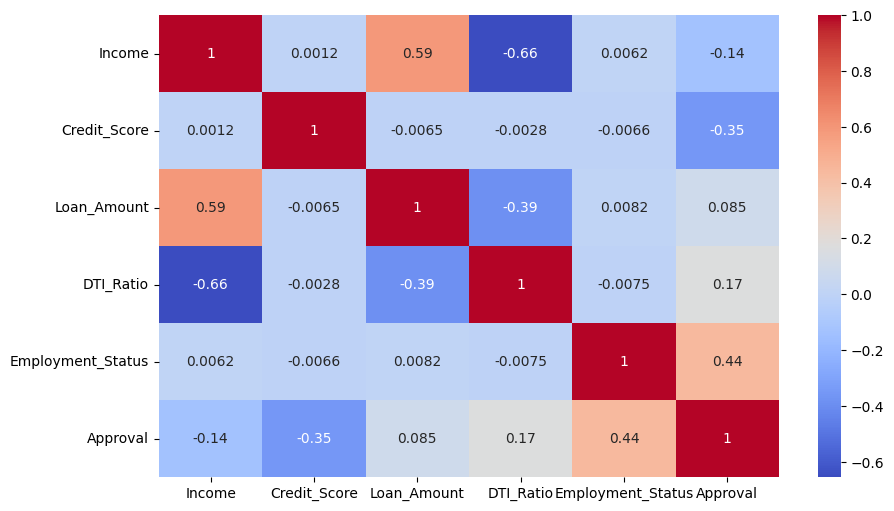

In [66]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

4. Model Building

In [67]:
from sklearn.model_selection import train_test_split

X = df.drop('Approval', axis=1)
y = df['Approval']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [69]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [71]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

Model Evaluation


In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [73]:
#For Logistic Regression
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1 Score:", f1_score(y_test, pred_lr))

Accuracy: 0.9283333333333333
Precision: 0.9584055459272097
Recall: 0.9565109957993575
F1 Score: 0.9574573336631215


In [74]:
#For Decision Tree
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Precision:", precision_score(y_test, pred_dt))
print("Recall:", recall_score(y_test, pred_dt))
print("F1 Score:", f1_score(y_test, pred_dt))

Accuracy: 0.9958333333333333
Precision: 0.9985144837831146
Recall: 0.9965406473931308
F1 Score: 0.9975265891664605


In [75]:
#For Random Forest
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1 Score:", f1_score(y_test, pred_rf))

Accuracy: 0.9983333333333333
Precision: 0.9992583436341161
Recall: 0.9987645169261181
F1 Score: 0.9990113692535838


In [76]:
#For SVM
print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))
print("F1 Score:", f1_score(y_test, pred_svm))

Accuracy: 0.843125
Precision: 0.843125
Recall: 1.0
F1 Score: 0.9148864021702272


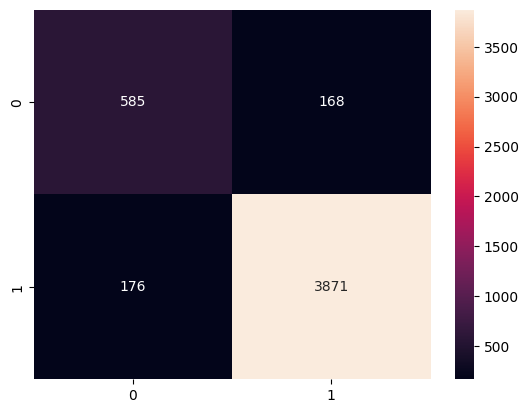

In [77]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

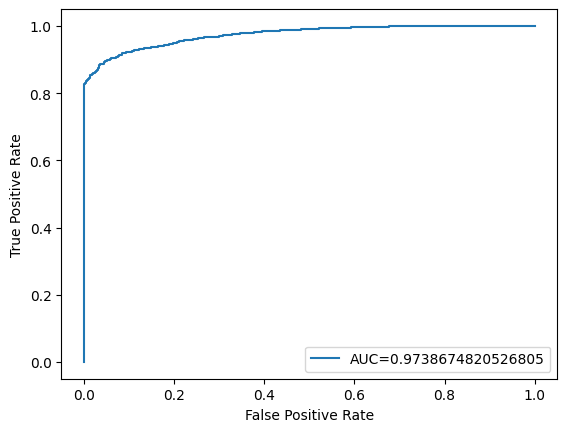

In [78]:
#ROC-AUC Curve
from sklearn.metrics import roc_curve, auc

prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC="+str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()